Import libraries

In [4]:
import os
import numpy as np
import pandas as pd

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist

import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kristupaskarbauskas/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kristupaskarbauskas/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kristupaskarbauskas/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading Renewables data

In [6]:
renewable = pd.read_csv('data/API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_372598.csv')

year_cols = [col for col in renewable.columns if col.isdigit()]

renewable_long = renewable.melt(id_vars=['Country Name', 'Country Code'], value_vars=year_cols,
                                 var_name='Year', value_name='Renewable_Share')
renewable_long['Year'] = renewable_long['Year'].astype(int)
renewable_long = renewable_long.rename(columns={'Country Code': 'ISO3'})

renewable_long = renewable_long[(renewable_long['Year'] >= 1990) & (renewable_long['Year'] <= 2020)]
renewable_long = renewable_long.dropna(subset=['Renewable_Share'])

renewable_long.head()

,Country Name,ISO3,Year,Renewable_Share
7950,Aruba,ABW,1990,0.300000
7951,Africa Eastern and Southern,AFE,1990,60.842404
7952,Afghanistan,AFG,1990,23.000000
7953,Africa Western and Central,AFW,1990,85.895442
7954,Angola,AGO,1990,72.300000


Loading the speeches

In [7]:
sessions = np.arange(45, 76)
data = []

for session in sessions:
    directory = "data/TXT/Session " + str(session) + " - " + str(1945+session)
    for filename in os.listdir(directory):
        if filename[0] == ".": #ignore hidden files
            continue
        with open(os.path.join(directory, filename), encoding="utf-8") as f:
            splt = filename.split("_")
            data.append([session, 1945+session, splt[0], f.read()])

df_speech = pd.DataFrame(data, columns=['Session', 'Year', 'ISO-alpha3 Code', 'Speech'])
df_speech.tail()

,Session,Year,ISO-alpha3 Code,Speech
5746,75,2020,HRV,"Mr President, Excellencies\nAll protocol obser..."
5747,75,2020,GAB,"Mr. President, Majesties,\nLadies and Gentleme..."
5748,75,2020,MCO,"Mr. President of the General Assembly,\nMr. Se..."
5749,75,2020,AND,"Mr. President,\nMr. Secretary General,\nYour E..."
5750,75,2020,BHR,"In the name of Allah, the most gracious, the m..."


In [8]:
merged = df_speech.merge(renewable_long, left_on=['ISO-alpha3 Code', 'Year'], right_on=['ISO3', 'Year'], how='inner')
merged = merged.drop(columns=['ISO3'])

merged.head()
print(merged.shape)

(5639, 6)


Cleaning and preprocessing

In [9]:
def preprocess(text):
    words = word_tokenize(text)
    words = [w.lower() for w in words]
    words = [w for w in words if w.isalpha()] #removes punctuation and numbers

    sw = stopwords.words("english")
    sw += ["united", "nations"] #not informative for this corpus

    words = [w for w in words if w not in sw]
    return words

In [10]:
merged["Words"] = merged["Speech"].apply(preprocess)
merged.head()

,Session,Year,ISO-alpha3 Code,Speech,Country Name,Renewable_Share,Words
0,45,1990,NZL,"﻿\nI should like to congratulate you, Sir, on ...",New Zealand,28.0,"[like, congratulate, sir, election, presidency..."
1,45,1990,EGY,"﻿First of all, I would like to extend may dele...","Egypt, Arab Rep.",9.0,"[would, like, extend, may, delegation, persona..."
2,45,1990,CPV,﻿I should like to begin by offering Mr. de Mar...,Cabo Verde,21.1,"[like, begin, offering, de, marco, sincere, co..."
3,45,1990,UGA,"﻿In 1967, I had the privilege of addressing th...",Uganda,96.6,"[privilege, addressing, assembly, session, too..."
4,45,1990,NLD,"﻿\nMay I, first of all, extend to Mr. de Marco...",Netherlands,1.2,"[may, first, extend, de, marco, congratulation..."


Analyzing climate speech intensity

In [11]:
climate_words = {
    # general climate change vocabulary
    "climate", "warming", "emission", "emissions", "greenhouse",
    "carbon", "co2", "fossil", "renewable", "renewables",
    "sustainability", "adaptation", "mitigation", "temperature", "glacier", "glaciers", "icecap",

    # drought
    "drought", "droughts", "arid", "aridity",

    # extreme temperature
    "heatwave", "heatwaves", "coldwave",

    # flood
    "flood", "floods", "flooding", "inundation", "inundated",

    # landslide
    "landslide", "landslides", "mudslide", "mudslides", "rockslide",

    # storm
    "storm", "storms", "cyclone", "cyclones", "hurricane", "hurricanes",
    "typhoon", "typhoons", "tornado", "tornadoes", "monsoon",

    # wildfire
    "wildfire", "wildfires", "bushfire", "bushfires"
}

def climate_intensity(words):
    freq = FreqDist(words)
    climate_count = sum(freq[w] for w in climate_words)
    return climate_count / len(words) * 1000

merged["Climate_Talk_Intensity"] = merged["Words"].apply(climate_intensity)
merged[["ISO-alpha3 Code", "Year", "Climate_Talk_Intensity"]].head()

,ISO-alpha3 Code,Year,Climate_Talk_Intensity
0,NZL,1990,1.889169
1,EGY,1990,0.892061
2,CPV,1990,5.484461
3,UGA,1990,0.000000
4,NLD,1990,2.152853


Merging everything into one analysis table

In [12]:
analysis_table = merged[["ISO-alpha3 Code", "Year", "Renewable_Share", "Climate_Talk_Intensity"]].copy()
analysis_table = analysis_table.set_index(["Year", "ISO-alpha3 Code"]).sort_index()

analysis_table.head()

Renewable_Share  Climate_Talk_Intensity
Year ISO-alpha3 Code                                         
1990 AFG                         23.0                0.000000
     AGO                         72.3                1.448226
     ALB                         25.5                0.000000
     ARE                          0.0                0.628141
     ARG                          8.6                0.768640

# Analysis

In [13]:
analysis_table.describe()

,Renewable_Share,Climate_Talk_Intensity
count,5639.000000,5639.000000
mean,33.886505,3.223551
std,30.629836,5.216290
min,0.000000,0.000000
25%,6.500000,0.000000
50%,24.600000,1.098901
75%,57.900000,4.092211
max,98.300000,43.745203


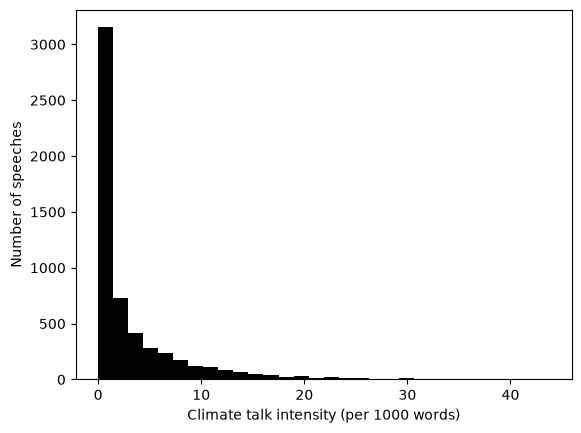

In [14]:
fig, ax = plt.subplots()
ax.hist(analysis_table["Climate_Talk_Intensity"], bins=30, color='black')
ax.set_xlabel("Climate talk intensity (per 1000 words)")
ax.set_ylabel("Number of speeches")
plt.show()

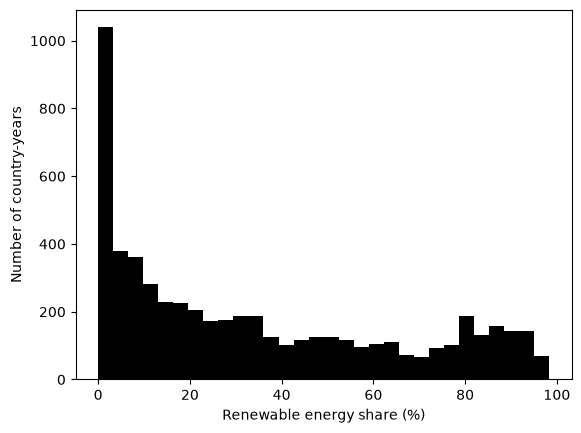

In [16]:
fig, ax = plt.subplots()
ax.hist(analysis_table["Renewable_Share"], bins=30, color='black')
ax.set_xlabel("Renewable energy share (%)")
ax.set_ylabel("Number of country-years")
plt.show()

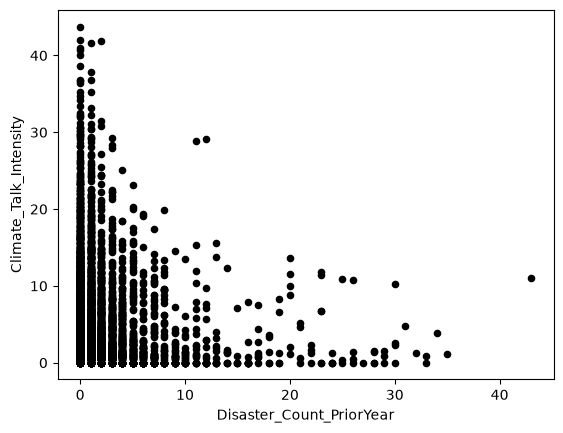

In [78]:
analysis_table.plot.scatter(x="Disaster_Count_PriorYear", y="Climate_Talk_Intensity", c='black')
plt.show()

In [17]:
corr = np.corrcoef(analysis_table["Renewable_Share"], analysis_table["Climate_Talk_Intensity"])[0, 1]
print("Correlation coefficient:", corr)

Correlation coefficient: -0.0374121132101902


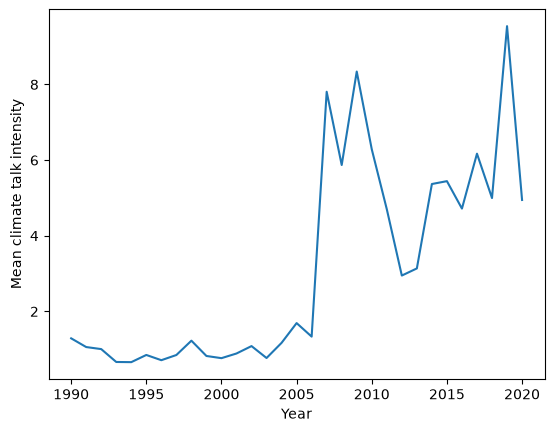

In [18]:
mean_by_year = analysis_table.groupby("Year")[["Renewable_Share", "Climate_Talk_Intensity"]].mean()

fig, ax = plt.subplots()
ax.plot(mean_by_year.index, mean_by_year["Climate_Talk_Intensity"])
ax.set_xlabel("Year")
ax.set_ylabel("Mean climate talk intensity")
plt.show()

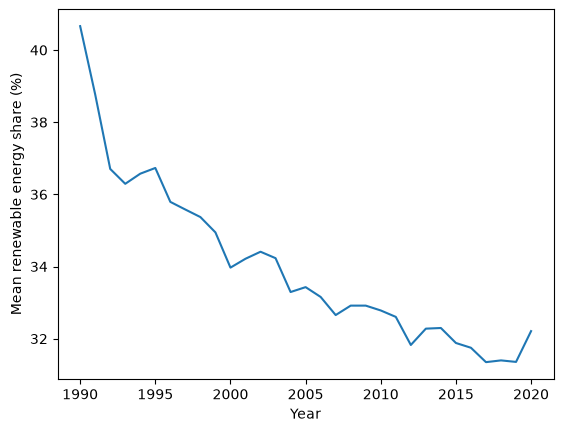

In [19]:
fig, ax = plt.subplots()
ax.plot(mean_by_year.index, mean_by_year["Renewable_Share"])
ax.set_xlabel("Year")
ax.set_ylabel("Mean renewable energy share (%)")
plt.show()